# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [3]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21


In [4]:
type(df.index[0])

pandas._libs.tslibs.timestamps.Timestamp

1. Скільки даних в наборі?

Ми маємо набір даних розміром 10886 рядків та 19 колонок (206 834 клітинки).

2. Який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

В одному рядку містяться дані за одну годину дня. (Наприклад, дані за 22 годину 19 грудня 2012 року, дані 3 годину 01 січня 2011 року)

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [5]:
count_by_days = df['count'].resample('D').sum()
count_by_days

,count
datetime,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
...,...
2012-12-15,5047
2012-12-16,3786
2012-12-17,4585


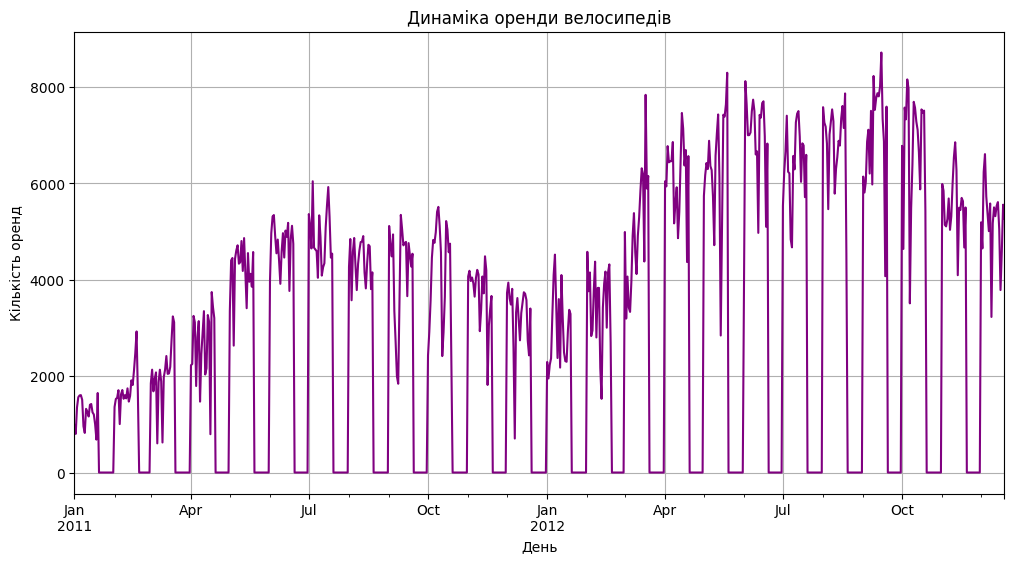

In [6]:
count_by_days.plot.line(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='День',
    ylabel='Кількість оренд',
    grid=True,
    color='purple',
);

1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?

Заломи пов'язані з тим, що в кінці кожного місяця кількість оренд дорівнює 0. Це бути спричинено як погодними умовами, так і місцевими традиціями, святами, віруваннями. Як один із варіантв вирішення проблеми, прибрати дні, коли кількість оренд = 0 із розрахунків.

2. Які загальні тенденції ви бачите на графіку?

По графіку видно, що кожного року кількість оренд зростає в першому півріччі, після цьогов другому півріччі починає спадати. При цьому є невелике просідання кількості оренд на початку 2 півріччя. Також, в кінці кожного місяця року, починаючи з 20 числа, ми бачимо стабільне падіння оренди велосипедів на 0.

3. Чи помітні якісь сезонні коливання?

Ми бачимо стабільно високу кількість оренд у Monsoon, збільшення кількісті оренд у Summer, зменшення кількості оренд у Post-Monsoon, стабільно низьку кількість оренд у Winter. Такі коливання повторюються кожного року.

4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?

Наявний період з аномально низьким (нульовим) значенням в кінці кожного місяця (з 20 числа до кінця місяця). Це може бути по'язано з погодними/культурними/релігійними особливостями країни, в нашому випадку Індії.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [7]:
mean_count_by_season = df.groupby(['year', 'season'])['count'].mean()
mean_count_by_season

year  season
2011  1          71.905518
      2         160.940746
      3         186.994872
      4         154.787125
2012  1         159.476889
      2         269.601757
      3         281.735380
      4         243.189466
Name: count, dtype: float64

In [8]:
mean_count_by_season.index

MultiIndex([(2011, 1),
            (2011, 2),
            (2011, 3),
            (2011, 4),
            (2012, 1),
            (2012, 2),
            (2012, 3),
            (2012, 4)],
           names=['year', 'season'])

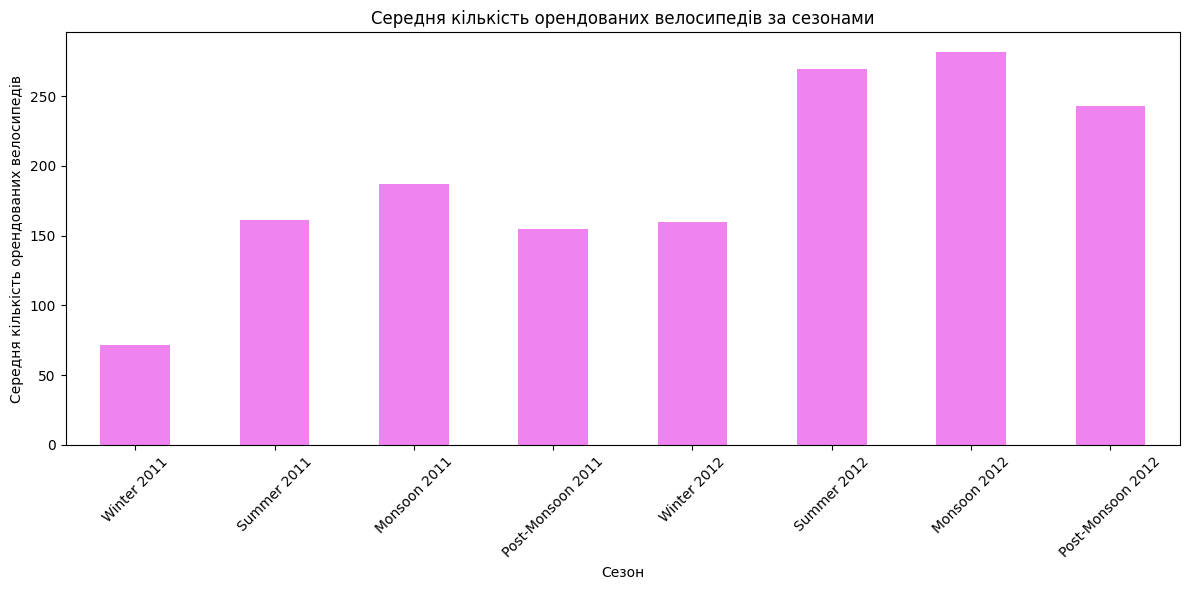

In [9]:
ax2 = mean_count_by_season.plot.bar(
    figsize=(12, 6),
    title='Середня кількість орендованих велосипедів за сезонами',
    xlabel='Сезон',
    ylabel='Середня кількість орендованих велосипедів',
    color='violet',
)

ax2.set_xticklabels(['Winter 2011', 'Summer 2011', 'Monsoon 2011', 'Post-Monsoon 2011', 'Winter 2012', 'Summer 2012', 'Monsoon 2012', 'Post-Monsoon 2012'])
plt.xticks(rotation=45)
plt.tight_layout()

Другий варіант виконання завдання:

In [10]:
mean_count_by_season_2 = df['count'].resample('QE').mean()
mean_count_by_season_2

,count
datetime,
2011-03-31,71.905518
2011-06-30,160.940746
2011-09-30,186.994872
2011-12-31,154.787125
2012-03-31,159.476889
2012-06-30,269.601757
2012-09-30,281.735380
2012-12-31,243.189466


In [11]:
mean_count_by_season_2.index

DatetimeIndex(['2011-03-31', '2011-06-30', '2011-09-30', '2011-12-31',
               '2012-03-31', '2012-06-30', '2012-09-30', '2012-12-31'],
              dtype='datetime64[ns]', name='datetime', freq='QE-DEC')

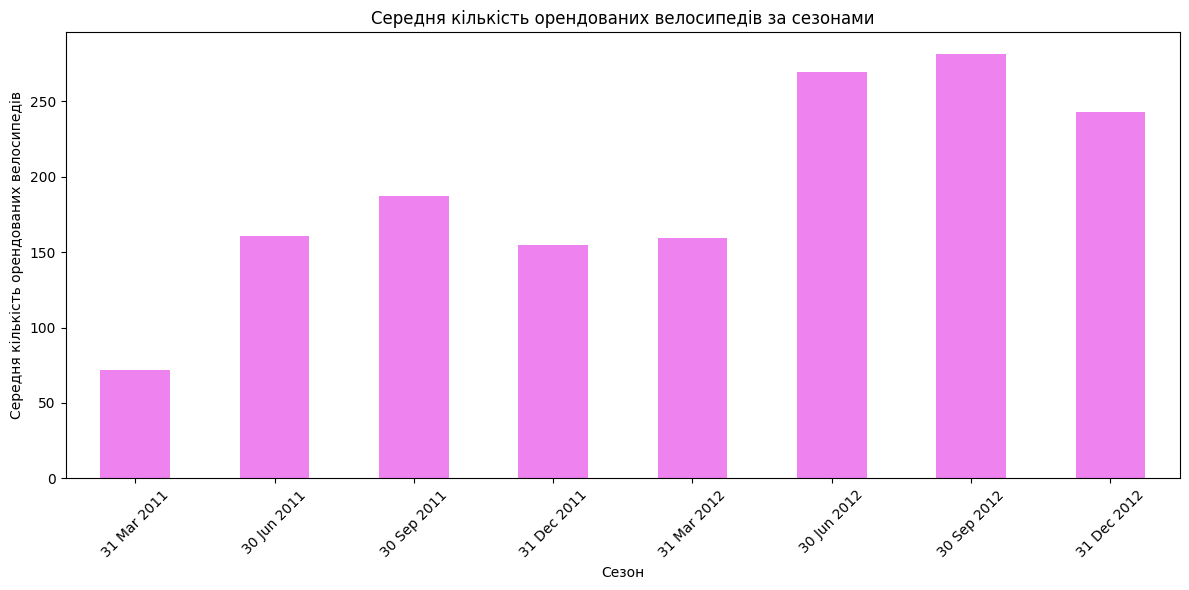

In [12]:
ax22 = mean_count_by_season_2.plot.bar(
    figsize=(12, 6),
    title='Середня кількість орендованих велосипедів за сезонами',
    xlabel='Сезон',
    ylabel='Середня кількість орендованих велосипедів',
    color='violet',
)

labels = [date.strftime('%d %b %Y') for date in mean_count_by_season_2.index]
ax22.set_xticklabels(labels)
plt.xticks(rotation=45)
plt.tight_layout()

1. В який квартал найбільша середня кількість оренди велосипедів?

Найбільша середня кількість оренди велосипедів - у сезон Monsoon.

2. Як ви можете пояснити таку сезонну закономірність?

Один із варіантів пояснення сезонної закономірності - погодні умови: під час сезону дощів можуть мати місце проблеми з транспортом, тому велосипед стає більш зручним засобом пересування. Ще одним варіантом пояснення сезонної закономірності - релігійні/культурні традиції країни: збільшується кількість ритуалів, обрядів -> підвищується попит на транспорт (дістатися до родичів, храмів).

3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталами?

Оренда між найпопулярнішим та найменш популярним сезонами відрізняється в 2-3 рази.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [13]:
mean_count_by_month = df.groupby('month')['count'].mean()
mean_count_by_month

,count
month,
1,90.366516
2,110.003330
3,148.169811
4,184.160616
5,219.459430
6,242.031798
7,235.325658
8,234.118421
9,233.805281


In [14]:
mean_count_by_month.index

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int32', name='month')

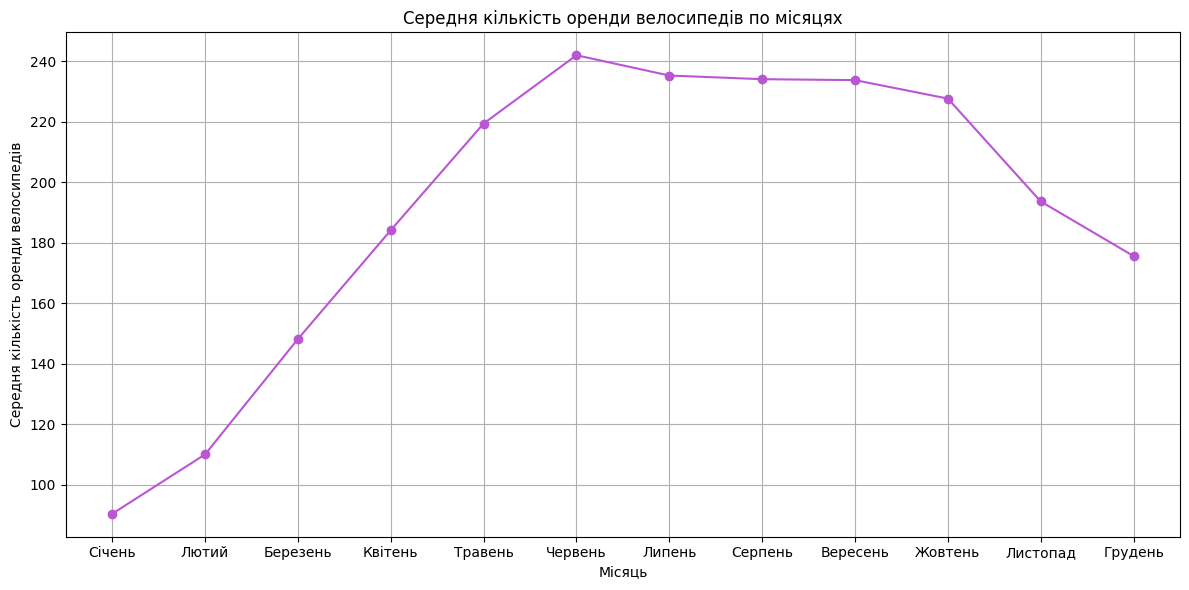

In [15]:
ax3 = mean_count_by_month.plot.line(
    figsize=(12, 6),
    marker='o',
    title='Середня кількість оренди велосипедів по місяцях',
    xlabel='Місяць',
    ylabel='Середня кількість оренди велосипедів',
    grid=True,
    color='mediumorchid',
)

plt.xticks(range(1, 13), ['Січень', 'Лютий', 'Березень', 'Квітень', 'Травень', 'Червень', 'Липень', 'Серпень', 'Вересень', 'Жовтень', 'Листопад', 'Грудень'])
plt.xlim(0.5, 12.5)
plt.tight_layout()

1. В які місяці спостерігається пік та спад оренди?

Пік оренди спостерігається в червні місяці. Спад оренди - з жовтня по січень.

2. Чи збігається ця закономірність з результатами з попереднього завдання?

Так, збігається. У місяці пост-мусону та зими ми бачимо низький попит на оренду велосипедів. В той час в період літа та мусону видно високий попит на оренду.

3. Як може вплинути клімат на оренду велосипедів протягом року?

З графіку видно вплив клімату на оренду велосипедів. З початком літа (березень місяць) і потеплінням збільшується попит на оренду. У сезон пост-мусону та зими (похолодання) видно поступове падіння попиту на оренду велосипедів.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

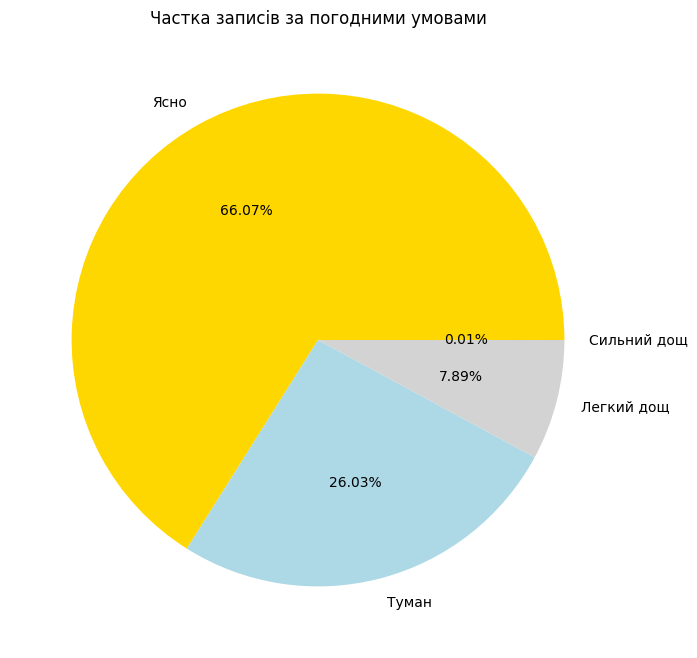

In [16]:
count_by_weather_pc = df.groupby('weather')['count'].sum()
count_by_weather_pc

,count
weather,
1,1476063
2,507160
3,102089
4,164


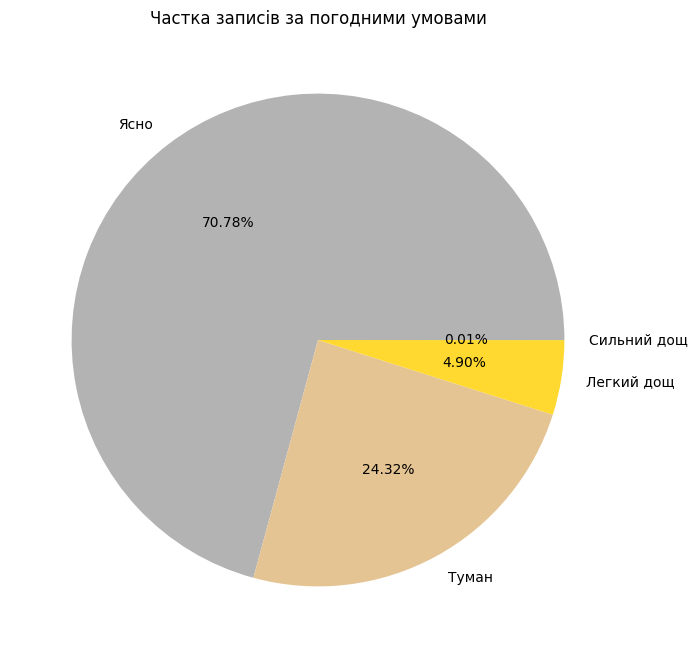

In [17]:
count_by_weather_pc.plot.pie(
    figsize=(8, 8),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка записів за погодними умовами',
    ylabel='',
    colors=plt.cm.Set2_r.colors
);

1. Яка погода переважає в датасеті?

В датасеті переважає ясна погода.

2. Чи є дні із сильним дощем? Яка їх частка?

Так, дні з сильним дощем наявні в датасеті. Але їх частка мінімальна і дорівнює 0,01%.

3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

За ясної погоди велосипед є дуже зручним траспортом для пересування. В той час як сильний дощ значно ускладнює можливості руху, максимально знижує видимість, підвищує ризик аварії, з'їзду з дороги, підвищує ризик захворіти після поїздки.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [18]:
count_by_weather_bp = df.groupby('weather')['count'].count()
count_by_weather_bp

,count
weather,
1,7192
2,2834
3,859
4,1


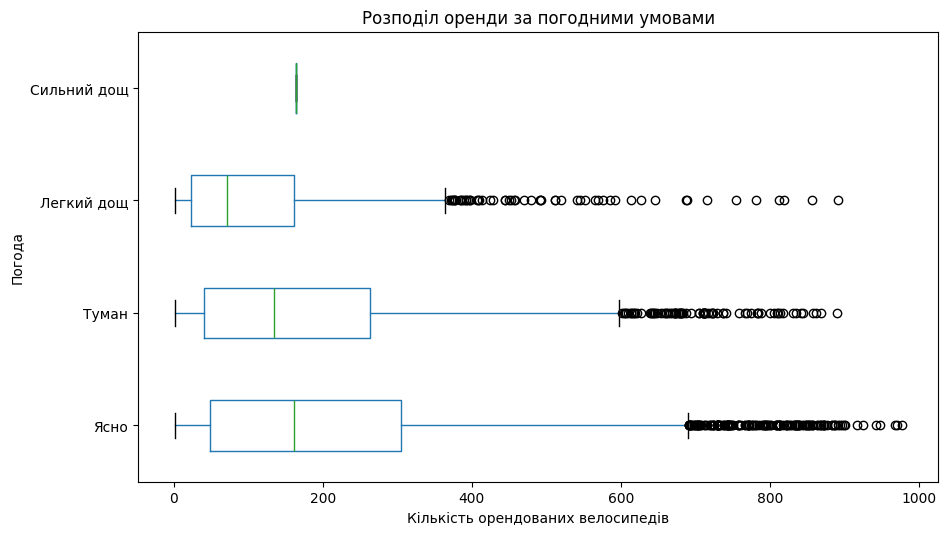

In [19]:
ax5 = df.boxplot(
    column='count',
    by='weather',
    figsize=(10, 6),
    grid = False,
    vert=False
)
plt.title('Розподіл оренди за погодними умовами')
plt.suptitle('')
plt.ylabel('Погода')
ax5.set_yticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.xlabel('Кількість орендованих велосипедів')
plt.show()

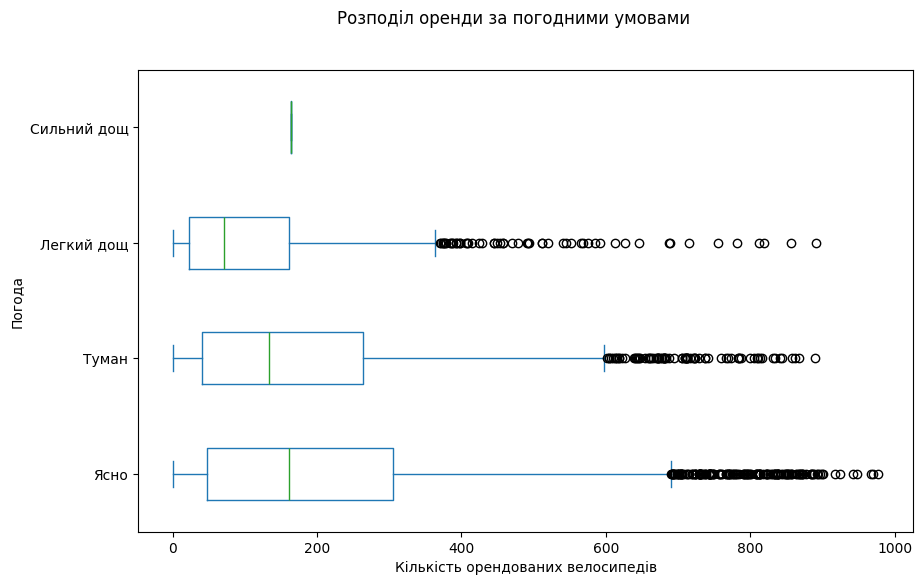

In [20]:
df[['count', 'weather']].plot.box(
    by='weather',
    figsize=(10, 6),
    vert=False,
    title='Розподіл оренди за погодними умовами',
    ylabel = 'Погода',
    xlabel='Кількість орендованих велосипедів'
)
plt.title('')
plt.yticks(range(1, 5), ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']);

1. При якій погоді найбільший розкид у кількості оренди?

Найбільший розкид у кількості оренди за ясної погоди.

2. Чи є викиди (outliers) в даних? При якій погоді?

Викиди в даних є за ясної погоди, туману та легкого дощу.

3. При якій погоді медіанне значення оренди найвище?

Медіанне значення оренди найвище за ясної погоди і за сильного дощу.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

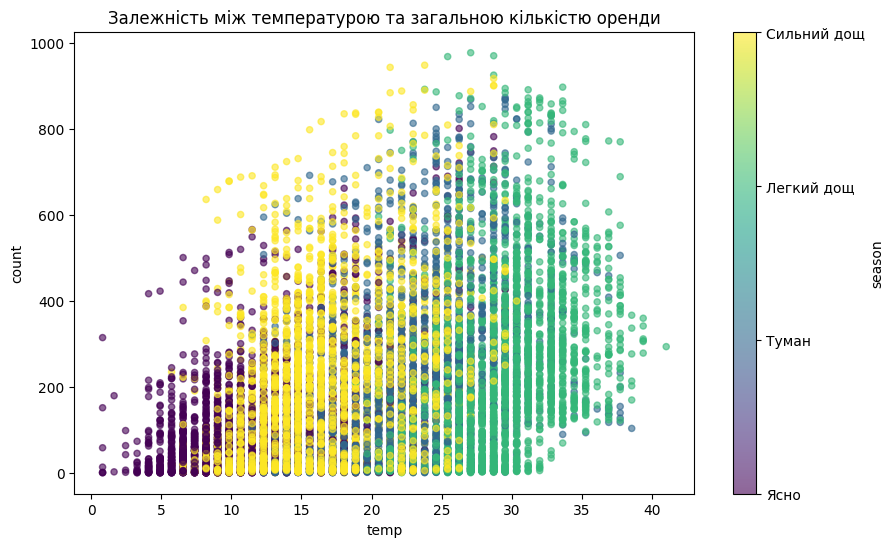

In [21]:
ax6 = df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    title='Залежність між температурою та загальною кількістю оренди',
    figsize=(10, 6),
    alpha=0.6
)

cbar = ax6.collections[0].colorbar
cbar.set_ticks([1, 2, 3, 4])
cbar.set_ticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])

plt.show()

Чи є зв'язок між температурою та кількістю оренди? Який?

Так, на графіку видно зв'язок між температурою та кількістю оренди. За температури від 20 до 30 градусів видно стабільно високий попит на оренду. Від 15 до 20 градусів - попит на оренду зростає. Від 30 до 40 градусів - попит спадає. Від 0 до 10 градусів - попит зростає, але він низький, якщо порівнювати з вищою температурою.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [22]:
week_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['weekday'] = pd.Categorical(df['weekday'], categories=week_days, ordered=True)
mean_count_by_weekday = df.groupby('weekday')[['casual', 'registered']].mean()
mean_count_by_weekday

/tmp/ipython-input-2680633004.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_count_by_weekday = df.groupby('weekday')[['casual', 'registered']].mean()


,casual,registered
weekday,,
Monday,29.843972,160.546744
Tuesday,22.979207,166.744639
Wednesday,22.521599,165.889749
Thursday,24.007083,173.289118
Friday,31.001962,166.842381
Saturday,63.625000,133.040404
Sunday,57.051298,123.788474


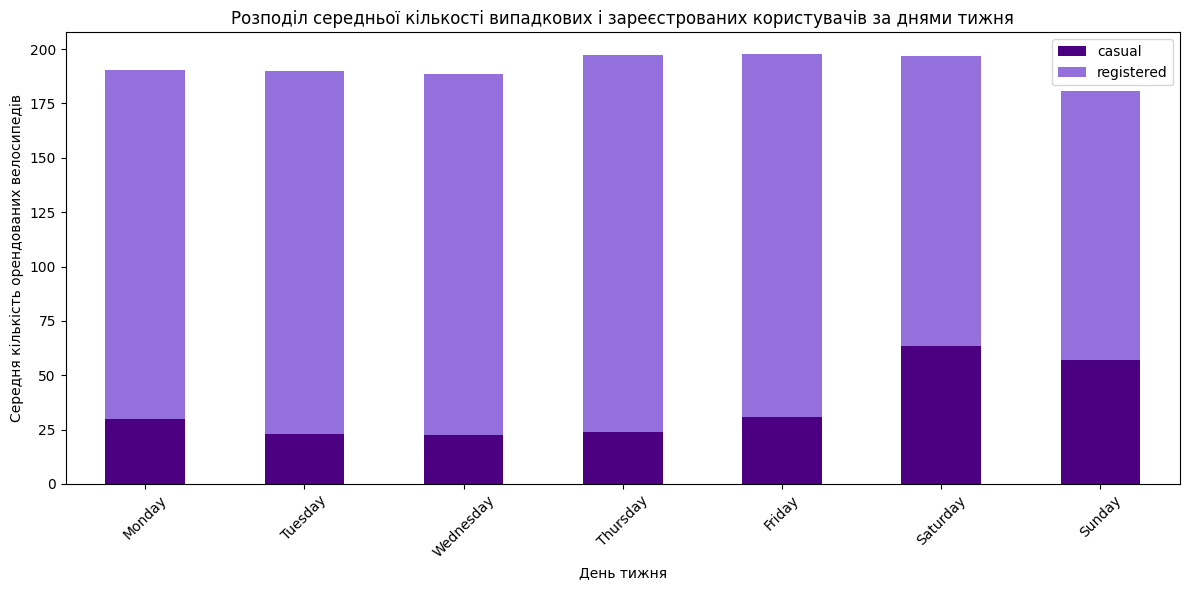

In [23]:
mean_count_by_weekday.plot.bar(
    figsize=(12, 6),
    title='Розподіл середньої кількості випадкових і зареєстрованих користувачів за днями тижня',
    xlabel='День тижня',
    ylabel='Середня кількість орендованих велосипедів',
    color=['indigo', 'mediumpurple'],
    stacked = True,
)

plt.xticks(rotation=45)
plt.tight_layout()

1. В які дні тижня більше оренд від зареєстрованих користувачів?

Від зареєстрованих користувачів більше оренд в робочі дні тижня (з понеділка по п'ятницю).

2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

На велосипеді зручніше дібратися до роботи вранці, а ввечері - додому. Також, можливо, в робочі дні тижня оренда велосипеда дешевша, ніж у вихідні.